# Ames Housing Sale Price Analysis

Messed up by Christina Craig

## Executive Summary

TODO: write an introduction using Markdown, explaining your high-level project goals and findings

## The Data

TODO: write a summary of the data source using Markdown

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline

file_path = "https://github.com/learn-co-curriculum/da-phase1-project-enterprise/raw/main/data/ames.csv"
ames_df = pd.read_csv(file_path, index_col=0)

In [2]:

print("The shape of the data frame is", ames_df.shape)
print("The first few rows look like this\r\n", ames_df.head())

The shape of the data frame is (1460, 80)
The first few rows look like this
     MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
Id                                                                    
1           60       RL         65.0     8450   Pave   NaN      Reg   
2           20       RL         80.0     9600   Pave   NaN      Reg   
3           60       RL         68.0    11250   Pave   NaN      IR1   
4           70       RL         60.0     9550   Pave   NaN      IR1   
5           60       RL         84.0    14260   Pave   NaN      IR1   

   LandContour Utilities LotConfig  ... PoolArea PoolQC Fence MiscFeature  \
Id                                  ...                                     
1          Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
2          Lvl    AllPub       FR2  ...        0    NaN   NaN         NaN   
3          Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
4          Lvl    AllPub    Corner  ... 

In [3]:
print("The column names of the data frame is", ames_df.columns)


The column names of the data frame is Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 

In [4]:
print("The info on the data frame is\r\n",ames_df.info)


The info on the data frame is
 <bound method DataFrame.info of       MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
Id                                                                      
1             60       RL         65.0     8450   Pave   NaN      Reg   
2             20       RL         80.0     9600   Pave   NaN      Reg   
3             60       RL         68.0    11250   Pave   NaN      IR1   
4             70       RL         60.0     9550   Pave   NaN      IR1   
5             60       RL         84.0    14260   Pave   NaN      IR1   
...          ...      ...          ...      ...    ...   ...      ...   
1456          60       RL         62.0     7917   Pave   NaN      Reg   
1457          20       RL         85.0    13175   Pave   NaN      Reg   
1458          70       RL         66.0     9042   Pave   NaN      Reg   
1459          20       RL         68.0     9717   Pave   NaN      Reg   
1460          20       RL         75.0     9937   Pave   NaN 

In [5]:
# pd.set_option("display.max_columns", 20)
# pd.set_option("display.max_rows", 20)

In [6]:
print("Do I have missing Data?\r\n\nThere is",ames_df.isna().value_counts().sum(), "null values at least.")


Do I have missing Data?

There is 1460 null values at least.


## Distribution of `SalePrice`

180921.19589041095


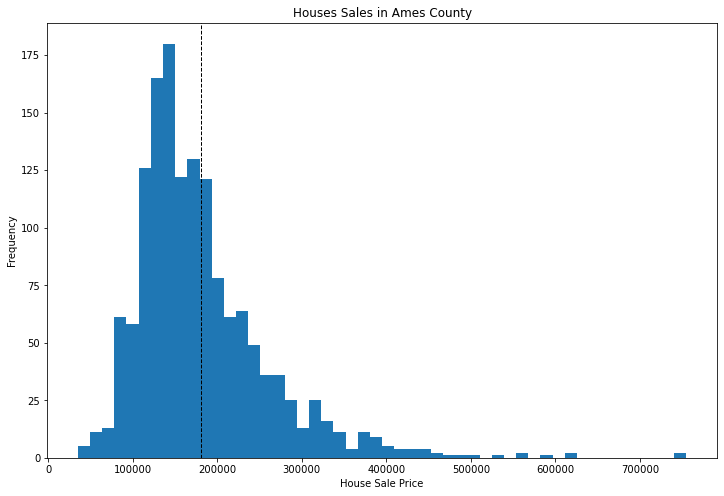

In [7]:
SalePrice_plot = ames_df['SalePrice']

print(SalePrice_plot.mean())

plt.xlabel("House Sale Price")

plt.ylabel("Number of Houses Sold")

plt.title("Houses Sales in Ames County")

SalePrice_plot.plot(x='SalePrice', kind='hist', bins = 50, figsize=(12,8))

plt.axvline(SalePrice_plot.mean(), color='k', linestyle='dashed', linewidth=1)

plt.show()

The distributions skews to the left more due the majority of the sales being in the 100k to 200k ranges of prices. But the mean is pulled towards the higher end of the range due to there being a few high dollar sales.

## Differences between Subsets

I'm breaking down the SalePrice by the different foundation types, no real reason besides I want to see which ones are most common. I was also tempted to break the subsets down further by using basement height/condition, but I'll sit on that idea for now.

In [8]:
Bktil = ames_df[ames_df["Foundation"] == 'BrkTil']

CBlock = ames_df[ames_df["Foundation"] == 'CBlock']

PConc = ames_df[ames_df["Foundation"] == 'PConc']

Slab = ames_df[ames_df["Foundation"] == 'Slab']

Stone = ames_df[ames_df["Foundation"] == 'Stone']

Wood = ames_df[ames_df["Foundation"] == 'Wood']

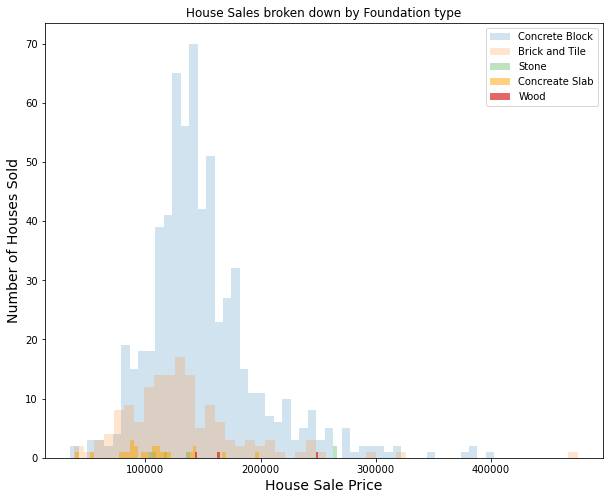

In [9]:
plt.figure(figsize=(10,8))

plt.hist(CBlock['SalePrice'], bins=50, alpha=.2, label="Concrete Block")
plt.hist(Bktil['SalePrice'], bins=50, alpha=.2, label="Brick and Tile")
plt.hist(Stone['SalePrice'], bins=50, alpha=.3, label="Stone")
plt.hist(Slab['SalePrice'], bins=50, alpha=.5, color='Orange', label="Concreate Slab")
plt.hist(Wood['SalePrice'], bins=50, alpha=.7, label="Wood")


plt.xlabel("House Sale Price", size=14)
plt.ylabel("Number of Houses Sold", size=14)
plt.title("House Sales broken down by Foundation type")

plt.legend(loc='upper right')

plt.show()


Going by the graph, you can see that concrete block and brick and tile foundations are by far the most common. To me, this shows that the soil there is deep enough to allow foundations to be dug, and there's possibly not a high water table there to cause major foundation issues.

## Correlation between `LotArea` and `SalePrice`


In [10]:
print('The correlation between LotArea and SalePrice is', ames_df['LotArea'].corr(ames_df['SalePrice']))

The correlation between LotArea and SalePrice is 0.2638433538714056


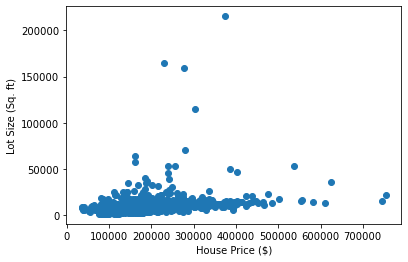

In [14]:
plt.scatter(x='SalePrice', y='LotArea', data=ames_df)

plt.xlabel("House Price ($)")
plt.ylabel("Lot Size (Sq. ft)")
plt.show()

Lot Size and Sale price has a very low correlation from the calculation. From the graph, we can see that there are large lots that sell for a lower price then a lot of other houses with a smaller lot. 

## Engineered Feature: [Lot_and_House]


In [16]:
ames_df['Lot_and_House'] = ames_df['LotArea'] + ames_df['GrLivArea']

The correlation between LotArea and SalePrice is 0.29666343633602077


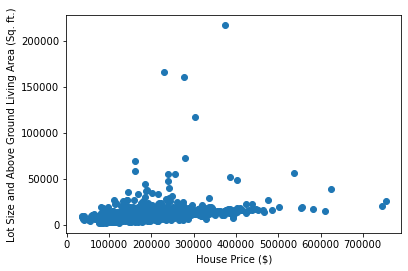

In [18]:
print('The correlation between Lot_and_House and SalePrice is', ames_df['Lot_and_House'].corr(ames_df['SalePrice']))

plt.scatter(x='SalePrice', y='Lot_and_House', data=ames_df)

plt.xlabel("House Price ($)")
plt.ylabel("Lot Size and Above Ground Living Area (Sq. ft.)")
plt.show()

When you add in the basic square footage of the house to the lot size, it only slightly increases the correllation between the footage to the house price.